# Held-out Dose Prediction and Pharmacology-aware Evaluation

## Objective

Test whether an unobserved drug–dose transcriptional state can be predicted from other observed conditions, and whether numerical state reconstruction implies pharmacological mechanism recovery.

## Representation caveat

PCA was fitted in Task 3 on the full dataset before the held-out prediction experiment. The prediction models themselves exclude the held-out dose during fitting, but the representation is therefore **transductive rather than strictly train-only**. A fully inductive benchmark would refit PCA within each training split. Results should be interpreted as condition-level prediction within a fixed global representation.

## Setup and data

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import Ridge
import gseapy as gp

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "README.md").exists():
    if (PROJECT_ROOT.parent / "README.md").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures" / "prediction"
RES_DIR = PROJECT_ROOT / "results"
TASK4_RES = RES_DIR / "task4"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(DATA_DIR / "processed" / "adata_perturbation_landscape.h5ad")


## Held-out design

A full drug–dose condition was held out: dose 10 µM (interpolation) and dose 100 µM (extrapolation). Models were compared on the same held-out condition and the same metrics.

In [2]:
DOSE_LIST = ['0', '0.1', '0.5', '1', '5', '10', '50', '100']
adata.obs['dose_num'] = pd.to_numeric(adata.obs['dose_value'].astype(str), errors='coerce')

cnt = adata.obs.groupby(['perturbation', 'dose_value'], observed=True).size().unstack(fill_value=0)
print("cell counts by drug and dose:")
cnt


cell counts by drug and dose:


dose_value,0,0.1,0.5,1,5,10,50,100
perturbation,,,,,,,,
BMS,959,902,703,506,435,292,137,126
Dex,886,897,824,1031,992,882,1115,1257
Nutlin,976,833,768,874,811,1069,395,80
SAHA,983,767,692,639,518,523,717,518


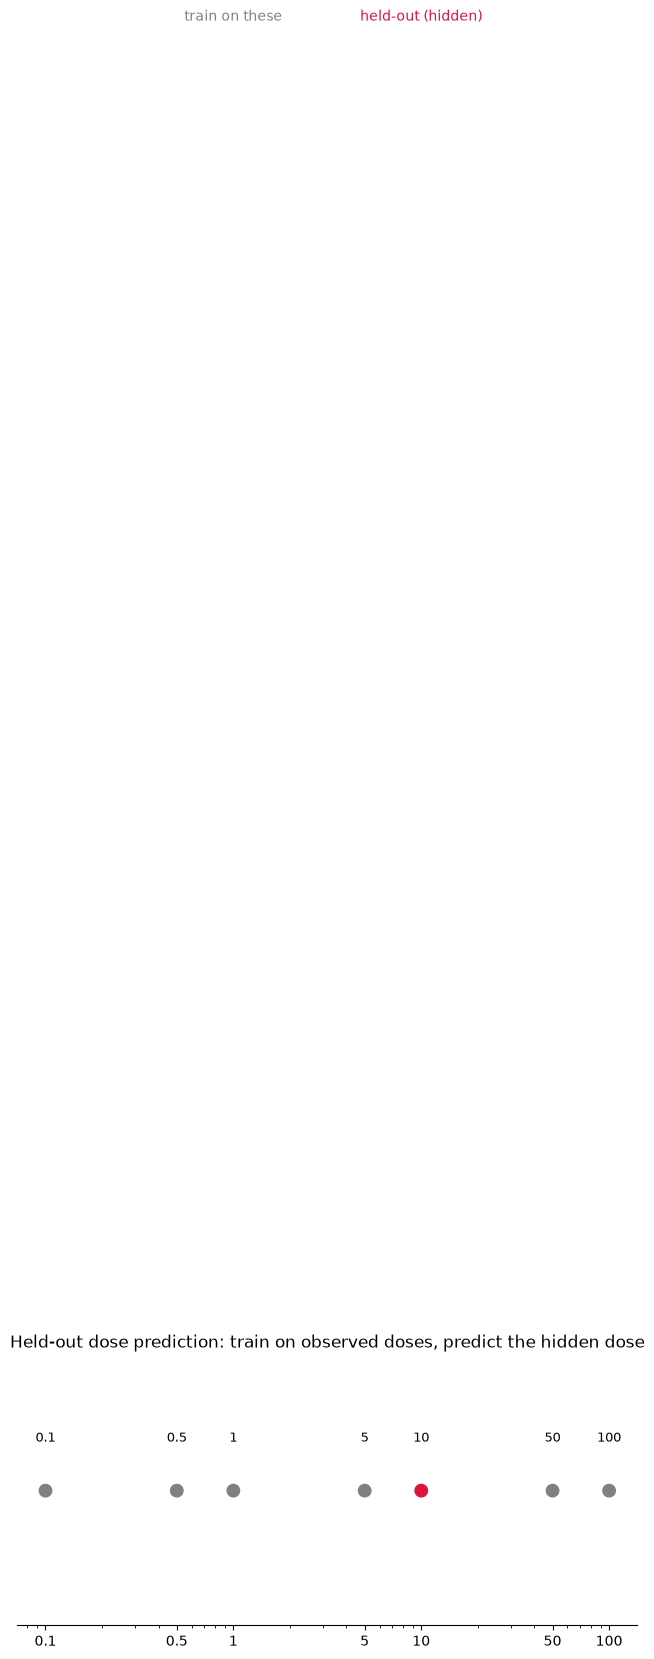

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.5))
doses = [0.1, 0.5, 1, 5, 10, 50, 100]
y = [0]*len(doses)
ax.scatter(doses, y, s=80, c=['gray' if d != 10 else 'crimson' for d in doses], zorder=3)
ax.annotate('held-out (hidden)', (10, 0), xytext=(10, 0.6), ha='center', color='crimson')
ax.annotate('train on these', (1, 0), xytext=(1, 0.6), ha='center', color='gray')
for d in doses:
    ax.annotate(f'{d}', (d, 0.02), ha='center', fontsize=9)
ax.set_xscale('log'); ax.set_xticks(doses); ax.set_xticklabels([str(d) for d in doses])
ax.set_yticks([]); ax.spines[['left','top','right']].set_visible(False)
ax.set_title('Held-out dose prediction: train on observed doses, predict the hidden dose')
fig.savefig(FIG_DIR / 'task5_prediction_design.png', dpi=300, bbox_inches='tight')
plt.show()


## Models and baselines

Four approaches were compared: control-state, nearest observed dose, log-dose linear interpolation, and ridge regression (log-dose → PC). The prediction target is the condition-level PCA centroid rather than individual-cell responses. Well-level structure is used elsewhere in the project for replicate-aware inference and reproducibility assessment.

In [4]:
N_PC = 30
X_pca = adata.obsm['X_pca'][:, :N_PC]
obs = adata.obs

def dose_centroid(drug, dose):
    m = (obs['perturbation'] == drug) & (obs['dose_value'].astype(str) == str(dose))
    return X_pca[m.values].mean(axis=0)

def get_centroids(drug):
    return {float(d): dose_centroid(drug, d) for d in DOSE_LIST
            if (obs['perturbation'] == drug).any()}

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

def interp_pred(cent, held, train):
    if held < min(train):
        lo, hi = sorted(train)[:2]
    elif held > max(train):
        lo, hi = sorted(train)[-2:]
    else:
        lo = max([d for d in train if d <= held])
        hi = min([d for d in train if d >= held])
    w = (np.log10(held) - np.log10(lo)) / (np.log10(hi) - np.log10(lo))
    return cent[lo] * (1 - w) + cent[hi] * w

def ridge_pred(cent, held, train):
    Xtr = np.log10(np.array(train)).reshape(-1, 1)
    Ytr = np.vstack([cent[d] for d in train])
    mdl = Ridge(alpha=1.0).fit(Xtr, Ytr)
    return mdl.predict(np.log10(np.array([[held]])))[0]

def run_heldout(drug, held):
    """Run full held-out prediction for drug at held dose; returns metrics dict"""
    cent = get_centroids(drug)
    train = sorted([d for d in cent if d > 0 and d != held])
    nearest = min(train, key=lambda d: abs(d - held))
    obs_vec = cent[held]
    ctrl = cent[0.0]

    preds = {
        'control': ctrl,
        'nearest': cent[nearest],
        'linear_interp': interp_pred(cent, held, train),
        'ridge': ridge_pred(cent, held, train),
    }
    metrics = {}
    for name, p in preds.items():
        metrics[name] = {
            'pca_error': float(np.linalg.norm(p - obs_vec)),
            'mag_ratio': float(np.linalg.norm(p - ctrl) / (np.linalg.norm(obs_vec - ctrl) + 1e-12)),
            'dir_cos': cosine(p - ctrl, obs_vec - ctrl),
        }
    return metrics, preds, obs_vec, ctrl

print("test:Nutlin held-out dose 10")
m, _, _, _ = run_heldout('Nutlin', 10.0)
for k, v in m.items():
    print(f"  {k:15s} pca_error={v['pca_error']:.3f}  mag_ratio={v['mag_ratio']:.3f}  dir_cos={v['dir_cos']:.3f}")


test:Nutlin held-out dose 10
  control         pca_error=4.761  mag_ratio=0.000  dir_cos=0.000
  nearest         pca_error=1.006  mag_ratio=0.866  dir_cos=0.985
  linear_interp   pca_error=1.076  mag_ratio=0.813  dir_cos=0.990
  ridge           pca_error=3.222  mag_ratio=0.482  dir_cos=0.803


## Predicted vs observed held-out state (PC1–PC2)

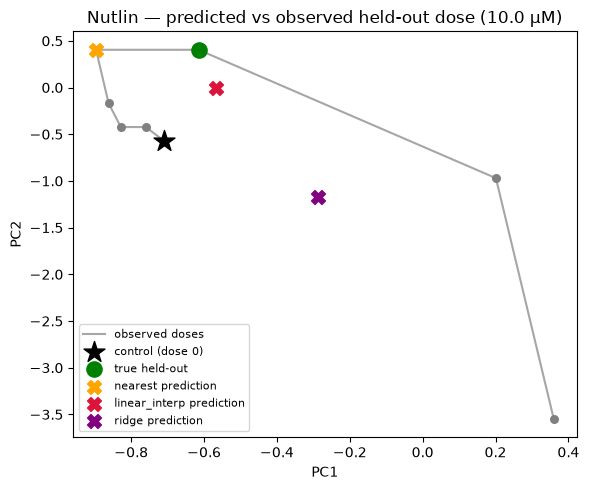

In [5]:
def plot_pred_vs_obs(drug, held, preds, obs_vec):
    cent = get_centroids(drug)
    ctrl = cent[0.0]
    fig, ax = plt.subplots(figsize=(6, 5))
    pts = np.array([cent[d] for d in sorted(cent)])
    ax.plot(pts[:, 0], pts[:, 1], '-', color='gray', lw=1.5, alpha=0.7, label='observed doses')
    ax.scatter(pts[:, 0], pts[:, 1], c='gray', s=30)
    ax.scatter(*ctrl[:2], marker='*', s=250, color='black', label='control (dose 0)', zorder=5)
    ax.scatter(*obs_vec[:2], marker='o', s=120, color='green', label='true held-out', zorder=5)
    colors = {'nearest': 'orange', 'linear_interp': 'crimson', 'ridge': 'purple'}
    for name in ['nearest', 'linear_interp', 'ridge']:
        ax.scatter(*preds[name][:2], marker='X', s=100, color=colors[name], label=f'{name} prediction', zorder=5)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'{drug} — predicted vs observed held-out dose ({held} µM)')
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'task5_predicted_vs_observed_pca.png', dpi=300, bbox_inches='tight')
    plt.show()

m, preds, obs_vec, _ = run_heldout('Nutlin', 10.0)
plot_pred_vs_obs('Nutlin', 10.0, preds, obs_vec)


## State-space results (all drugs × tasks)

In [6]:
rows = []
for drug in ['Nutlin', 'SAHA']:
    for held, task in [(10.0, 'interpolation'), (100.0, 'extrapolation')]:
        metrics, _, _, _ = run_heldout(drug, held)
        for model, v in metrics.items():
            rows.append({'drug': drug, 'task': task, 'model': model, **v})

summary = pd.DataFrame(rows)
summary.round(3)


,drug,task,model,pca_error,mag_ratio,dir_cos
0,Nutlin,interpolation,control,4.761,0.000,0.000
1,Nutlin,interpolation,nearest,1.006,0.866,0.985
2,Nutlin,interpolation,linear_interp,1.076,0.813,0.990
3,Nutlin,interpolation,ridge,3.222,0.482,0.803
4,Nutlin,extrapolation,control,3.990,0.000,0.000
5,Nutlin,extrapolation,nearest,4.171,0.985,0.445
6,Nutlin,extrapolation,linear_interp,3.724,1.016,0.571
7,Nutlin,extrapolation,ridge,5.379,1.194,0.254
8,SAHA,interpolation,control,9.158,0.000,0.000
9,SAHA,interpolation,nearest,0.898,0.942,0.997


In [7]:
summary.to_csv(RES_DIR / 'prediction_metrics.csv', index=False)
print('saved prediction_metrics.csv')


saved prediction_metrics.csv


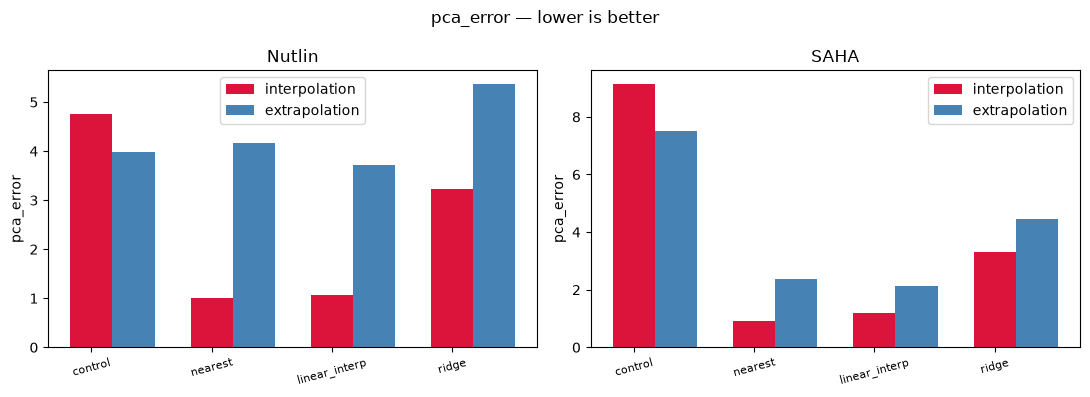

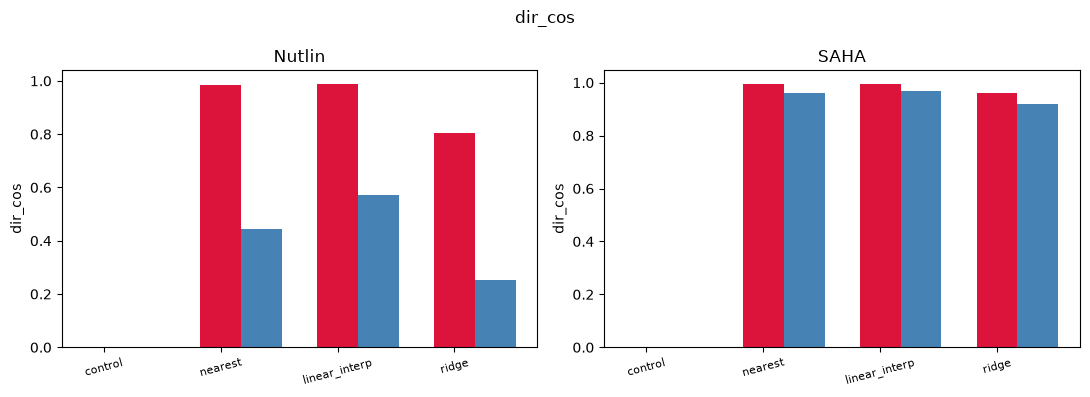

In [8]:
def plot_model_error(summary, metric='pca_error', fname='task5_model_error.png'):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, drug in zip(axes, ['Nutlin', 'SAHA']):
        sub = summary[summary['drug'] == drug]
        for task, color in [('interpolation', 'crimson'), ('extrapolation', 'steelblue')]:
            d = sub[sub['task'] == task]
            x = np.arange(len(d['model'].unique()))
            vals = [d[d['model'] == m][metric].values[0] for m in d['model'].unique()]
            ax.bar(x + (0 if task=='interpolation' else 0.35), vals, 0.35, color=color, label=task)
        ax.set_xticks(range(len(d['model'].unique())))
        ax.set_xticklabels(d['model'].unique(), rotation=15, fontsize=8)
        ax.set_title(drug); ax.set_ylabel(metric)
        if metric == 'pca_error':
            ax.legend()
    fig.suptitle(f'{metric} — lower is better' if metric=='pca_error' else metric)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

plot_model_error(summary, 'pca_error', 'task5_model_error.png')
plot_model_error(summary, 'dir_cos', 'task5_direction_recovery.png')


## Magnitude recovery

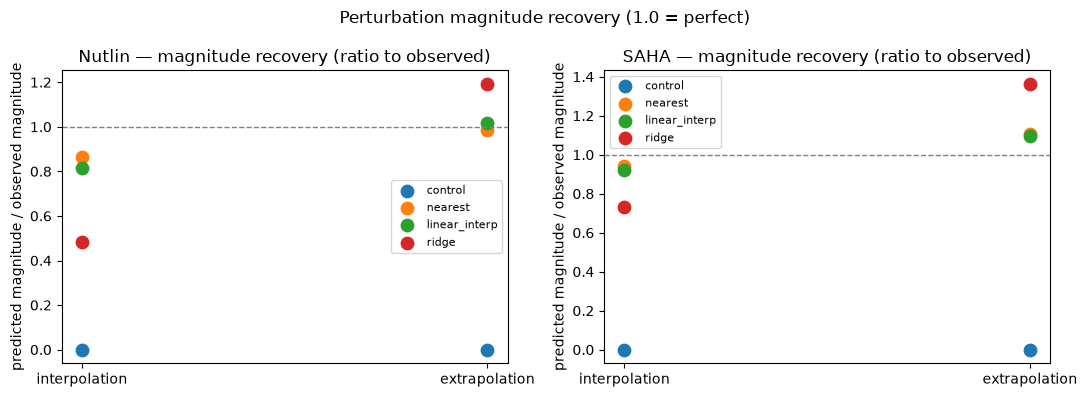

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, drug in zip(axes, ['Nutlin', 'SAHA']):
    sub = summary[summary['drug'] == drug]
    for model in ['control', 'nearest', 'linear_interp', 'ridge']:
        d = sub[sub['model'] == model]
        ax.scatter(d['task'], d['mag_ratio'], s=80, label=model)
    ax.axhline(1.0, color='gray', ls='--', lw=1)
    ax.set_title(f'{drug} — magnitude recovery (ratio to observed)')
    ax.set_ylabel('predicted magnitude / observed magnitude'); ax.legend(fontsize=8)
fig.suptitle('Perturbation magnitude recovery (1.0 = perfect)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'task5_magnitude_recovery.png', dpi=300, bbox_inches='tight')
plt.show()


## Gene-level recovery

Whole-transcriptome correlation saturates because most genes are unchanged; response-gene correlation is the discriminating metric.

Gene-level predictions are approximate reconstructions from the truncated 30-PC representation rather than outputs of a model trained directly in gene-expression space.

In [10]:
gene_mean = np.asarray(adata.X.mean(axis=0)).ravel()
PCs30 = np.asarray(adata.varm['PCs'])[:, :N_PC]   # (58347, 30)

def to_gene(pc30):
    return gene_mean + PCs30 @ pc30   # 30-PC subspace reconstruction

def load_response_genes(drug):
    deg = pd.read_csv(TASK4_RES / f"{'nutlin' if drug=='Nutlin' else 'vorinostat'}_deg.csv", index_col=0)
    return deg[(deg['padj'] < 0.05) & (deg['log2FoldChange'].abs() > 1)].index.tolist()

def gene_correlations(drug, held, preds, obs_vec):
    ctrl = get_centroids(drug)[0.0]
    obs_g = to_gene(obs_vec)
    ctrl_g = to_gene(ctrl)
    resp = load_response_genes(drug)
    out = {}
    for name, p in preds.items():
        pred_g = to_gene(p)
        out[name] = {
            'corr_all': float(np.corrcoef(pred_g, obs_g)[0, 1]),
            'corr_resp': float(np.corrcoef(pred_g[adata.var_names.isin(resp)], obs_g[adata.var_names.isin(resp)])[0, 1]),
        }
    return out, obs_g, ctrl_g

print("=== Nutlin held-out 10  gene correlation (all vs response genes) ===")
m, preds, obs_vec, _ = run_heldout('Nutlin', 10.0)
gc, obs_g, ctrl_g = gene_correlations('Nutlin', 10.0, preds, obs_vec)
for k, v in gc.items():
    print(f"  {k:15s} all={v['corr_all']:.3f}  response={v['corr_resp']:.3f}")


=== Nutlin held-out 10  gene correlation (all vs response genes) ===
  control         all=0.994  response=0.797
  nearest         all=1.000  response=0.996
  linear_interp   all=1.000  response=0.996
  ridge           all=0.997  response=0.942


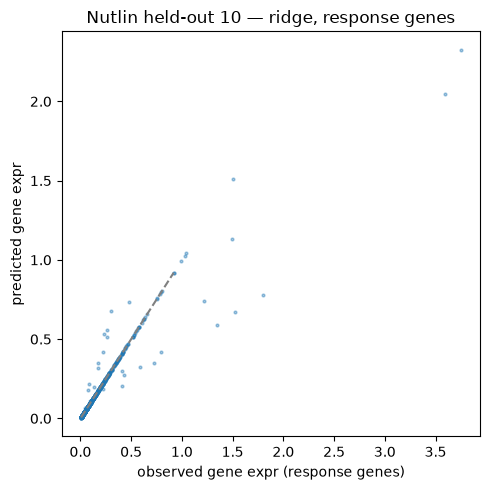

In [11]:
m, preds, obs_vec, _ = run_heldout('Nutlin', 10.0)
pred_g = to_gene(preds['ridge'])
resp = load_response_genes('Nutlin')
mask = adata.var_names.isin(resp)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(obs_g[mask], pred_g[mask], s=4, alpha=0.4)
lim = [np.percentile(np.r_[obs_g[mask], pred_g[mask]], 1), np.percentile(np.r_[obs_g[mask], pred_g[mask]], 99)]
ax.plot(lim, lim, '--', color='gray')
ax.set_xlabel('observed gene expr (response genes)'); ax.set_ylabel('predicted gene expr')
ax.set_title('Nutlin held-out 10 — ridge, response genes')
fig.tight_layout()
fig.savefig(FIG_DIR / 'task5_gene_prediction.png', dpi=300, bbox_inches='tight')
plt.show()


## DEG and pathway recovery

Predicted perturbation was mapped back to gene space (30-PC reconstruction) and compared with Task 4 DEGs and Hallmark programs.

DEG recovery is evaluated as overlap between matched top-K observed and predicted response genes, rather than between unequal-sized gene sets. Observed and predicted pathway enrichment were computed from matched top-200 upregulated gene lists using the same Hallmark over-representation analysis.

Exact top-200 gene recovery was low across all models, despite high response-gene correlation for local interpolation. This discrepancy further illustrates that low-dimensional state reconstruction does not guarantee recovery of the strongest individual response genes.

In [12]:
def deg_recovery(drug, held, preds, K=200):
    ctrl = get_centroids(drug)[0.0]
    deg = pd.read_csv(TASK4_RES / f"{'nutlin' if drug == 'Nutlin' else 'vorinostat'}_deg.csv", index_col=0)
    observed_up = set(deg.sort_values('log2FoldChange', ascending=False).head(K).index)
    observed_dn = set(deg.sort_values('log2FoldChange', ascending=True).head(K).index)
    out = {}
    for name, p in preds.items():
        pred_fc = to_gene(p) - to_gene(ctrl)
        pred_up = set(adata.var_names[np.argsort(-pred_fc)[:K]])
        pred_dn = set(adata.var_names[np.argsort(pred_fc)[:K]])
        out[name] = {
            'overlap_up': len(pred_up & observed_up),
            'overlap_dn': len(pred_dn & observed_dn),
            'precision_up': len(pred_up & observed_up) / K,
            'precision_dn': len(pred_dn & observed_dn) / K,
            'jaccard_up': len(pred_up & observed_up) / len(pred_up | observed_up),
            'jaccard_dn': len(pred_dn & observed_dn) / len(pred_dn | observed_dn),
        }
    return out

print("=== Nutlin held-out 10: DEG recovery (matched top-200) ===")
m, preds, obs_vec, _ = run_heldout("Nutlin", 10.0)
dr = deg_recovery("Nutlin", 10.0, preds)
for k, v in dr.items():
    print(k, v)


=== Nutlin held-out 10: DEG recovery (matched top-200) ===
control {'overlap_up': 0, 'overlap_dn': 0, 'precision_up': 0.0, 'precision_dn': 0.0, 'jaccard_up': 0.0, 'jaccard_dn': 0.0}
nearest {'overlap_up': 6, 'overlap_dn': 6, 'precision_up': 0.03, 'precision_dn': 0.03, 'jaccard_up': 0.015228426395939087, 'jaccard_dn': 0.015228426395939087}
linear_interp {'overlap_up': 6, 'overlap_dn': 7, 'precision_up': 0.03, 'precision_dn': 0.035, 'jaccard_up': 0.015228426395939087, 'jaccard_dn': 0.017811704834605598}
ridge {'overlap_up': 6, 'overlap_dn': 7, 'precision_up': 0.03, 'precision_dn': 0.035, 'jaccard_up': 0.015228426395939087, 'jaccard_dn': 0.017811704834605598}


In [13]:
def _enrichr_retry(gene_list, gene_sets='MSigDB_Hallmark_2020', retries=6):
    import time
    for a in range(retries):
        try:
            return gp.enrichr(gene_list=gene_list, gene_sets=gene_sets, outdir=None, no_plot=True)
        except Exception:
            if a == retries - 1:
                raise
            time.sleep(6)

def pathway_recovery(drug, held, preds, K=200):
    ctrl = get_centroids(drug)[0.0]
    deg = pd.read_csv(TASK4_RES / f"{'nutlin' if drug == 'Nutlin' else 'vorinostat'}_deg.csv", index_col=0)
    observed_up = list(deg.sort_values('log2FoldChange', ascending=False).head(K).index)
    obs_enr = _enrichr_retry(observed_up).results[['Term', 'Adjusted P-value']].sort_values('Adjusted P-value').head(10)
    results = {'observed': obs_enr}
    for name, p in preds.items():
        pred_fc = to_gene(p) - to_gene(ctrl)
        pred_up = list(adata.var_names[np.argsort(-pred_fc)[:K]])
        enr = _enrichr_retry(pred_up)
        results[name] = enr.results[['Term', 'Adjusted P-value']].sort_values('Adjusted P-value').head(10)
    return results

print("=== Nutlin held-out 10: ridge-predicted top pathways ===")
m, preds, obs_vec, _ = run_heldout("Nutlin", 10.0)
pr = pathway_recovery("Nutlin", 10.0, preds)
pr["ridge"].head(6)


=== Nutlin held-out 10: ridge-predicted top pathways ===


,Term,Adjusted P-value
0,mTORC1 Signaling,0.007411
1,Androgen Response,0.009887
2,UV Response Dn,0.039657
3,Estrogen Response Early,0.039657
4,Hypoxia,0.100711
5,Estrogen Response Late,0.100711


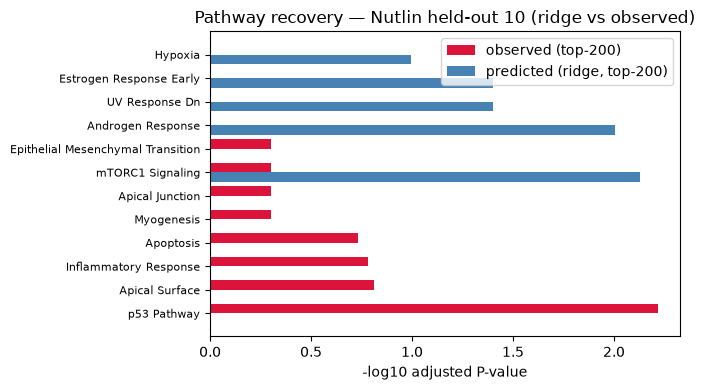

In [14]:
obs_top = pr['observed'].head(8)
pred_top = pr['ridge'].head(8)

fig, ax = plt.subplots(figsize=(7, 4))
terms = list(obs_top['Term']) + [t for t in pred_top['Term'] if t not in list(obs_top['Term'])]
terms = terms[:12]
obs_score = {r['Term']: -np.log10(r['Adjusted P-value']) for _, r in obs_top.iterrows()}
pred_score = {r['Term']: -np.log10(r['Adjusted P-value']) for _, r in pred_top.iterrows()}
x = np.arange(len(terms))
ax.barh(x + 0.2, [obs_score.get(t, 0) for t in terms], height=0.4, color='crimson', label='observed (top-200)')
ax.barh(x - 0.2, [pred_score.get(t, 0) for t in terms], height=0.4, color='steelblue', label='predicted (ridge, top-200)')
ax.set_yticks(x); ax.set_yticklabels(terms, fontsize=8)
ax.set_xlabel('-log10 adjusted P-value'); ax.legend()
ax.set_title('Pathway recovery — Nutlin held-out 10 (ridge vs observed)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'task5_pathway_recovery.png', dpi=300, bbox_inches='tight')
plt.show()


In [15]:
deg_rows = []
for drug in ['Nutlin', 'SAHA']:
    for held, task in [(10.0, 'interpolation'), (100.0, 'extrapolation')]:
        m, preds, _, _ = run_heldout(drug, held)
        dr = deg_recovery(drug, held, preds)
        for model, v in dr.items():
            deg_rows.append({'drug': drug, 'task': task, 'model': model, **v})
pd.DataFrame(deg_rows).round(4).to_csv(RES_DIR / 'deg_recovery.csv', index=False)
print('saved deg_recovery.csv')

path_rows = []
for drug in ['Nutlin', 'SAHA']:
    for held, task in [(10.0, 'interpolation'), (100.0, 'extrapolation')]:
        m, preds, _, _ = run_heldout(drug, held)
        pr = pathway_recovery(drug, held, preds)
        if not pr['ridge'].empty:
            sub = pr['ridge'].copy(); sub['drug'] = drug; sub['task'] = task
            path_rows.append(sub)
pd.concat(path_rows).to_csv(RES_DIR / 'pathway_recovery.csv', index=False)
print('saved pathway_recovery.csv')


saved deg_recovery.csv


saved pathway_recovery.csv


## Pharmacological Interpretation

For the Nutlin-3a 10 µM interpolation task, local dose-based baselines (nearest-dose, log-dose interpolation) recovered the held-out state more accurately than the global ridge model:

| Model | PCA error | Direction cosine |
|---|---:|---:|
| Control | 4.76 | — |
| Nearest dose | 1.01 | ≈ 0.99 |
| Log-dose interpolation | 1.08 | ≈ 0.99 |
| Ridge | 3.22 | ≈ 0.80 |

Response-gene correlation: nearest / interpolation ≈ 0.996, ridge ≈ 0.942, control ≈ 0.797. Despite partially reconstructing the held-out state, the ridge model failed to recover the dominant observed Nutlin-3a p53-associated program. **State-space reconstruction and pharmacological mechanism recovery are not equivalent** — the central finding of this analysis.

## Limitations

- Held-out dose prediction is easier than unseen-drug or out-of-distribution generalization.
- The PCA representation is transductive (see caveat above).
- The model predicts population-level average state, not single-cell distributions.
- gene- and pathway-level recovery is evaluated after approximate reconstruction from a truncated 30-PC representation.

## Summary

This analysis motivates future evaluation of perturbation models across drugs, cellular contexts, time, and exposure, with greater emphasis on mechanism recovery and out-of-distribution generalization.